# Fetal Head Abnormality Detection

Segmentation of the fetal head in ultrasound images with a U-Net, using a combined dataset of real HC18 images and quality-filtered synthetic images.

## Overview

Accurate fetal head segmentation is the basis for measuring head circumference (HC), a standard indicator used to screen for abnormal fetal head growth. Annotated ultrasound data is scarce, so this notebook augments the real training set with synthetic images and keeps only the synthetic images that pass a quality check.

| Stage | What happens | Section |
|---|---|---|
| 1 | Load and extract the dataset | 1 |
| 2 | Configure paths and output folders | 2 |
| 3 | Filter generated images by SSIM against a real reference | 3 |
| 4 | Measure realism of the filtered set with FID | 4 |
| 5 | Merge real and filtered synthetic pairs into one dataset | 5 |
| 6 | Define the dataset class and U-Net | 6 |
| 7 | Define loss and metrics (Dice, IoU) | 7 |
| 8 | Train and validate | 8 |
| 9 | Plot training curves and export the model | 9 |

## Contents

1. Dataset upload and extraction
2. Configuration
3. Synthetic image filtering (SSIM)
4. Realism check (FID)
5. Combined dataset
6. Dataset class and U-Net model
7. Loss function and metrics
8. Training
9. Results and export
10. Limitations and next steps

## Requirements

Python 3.9+, PyTorch, torchvision, NumPy, OpenCV, scikit-image, Pillow, Matplotlib and pytorch-fid. The full list is in `requirements.txt` in the repository. The notebook is written for Google Colab; a GPU runtime (Runtime > Change runtime type) speeds up Section 8 considerably.

## Expected dataset layout

The notebook expects a zip file named `train.zip` (HC18 training set) with this structure:

```
train/
  images/   # ultrasound images (PNG)
  masks/    # binary head masks with the same file names as the images
```

The HC18 dataset is available from the Grand Challenge "HC18" page (Zenodo mirror: 1327317). It is not included in this repository.

## How to run

1. Open the notebook in Colab and select a GPU runtime.
2. Run all cells in order (Runtime > Run all).
3. When Section 1 prompts for a file, upload `train.zip`.

## 1. Dataset upload and extraction

Uploads the dataset zip through the Colab file picker, extracts it to `/content/dataset`, and prints the first two directory levels as a sanity check. Expected result: `train/images/` and `train/masks/`.

In [ ]:
from google.colab import files
import zipfile, os

# Upload your zip file
uploaded = files.upload()  # Select your zip when prompted

# Get the uploaded filename automatically
zip_filename = list(uploaded.keys())[0]
print(f"Uploaded: {zip_filename}")

# Extract to /content/
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Extraction complete!")

# Check what's inside
for root, dirs, files_list in os.walk('/content/dataset'):
    level = root.replace('/content/dataset', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:  # Only show 2 levels deep
        for f in files_list[:5]:  # Show first 5 files only
            print(f'{indent}  {f}')


Saving train.zip to train.zip
Uploaded: train.zip
Extraction complete!
dataset/
  train/
    images/
    masks/


## 2. Configuration

All input and output paths are defined in one place so the rest of the notebook only refers to these variables.

| Variable | Purpose |
|---|---|
| `REAL_IMAGES_DIR`, `REAL_MASKS_DIR` | Real HC18 images and masks |
| `GENERATED_IMAGES_DIR`, `SYN_MASKS_DIR` | Generated (synthetic) images and their masks |
| `FILTERED_OUTPUT_DIR` | Synthetic images that pass the SSIM filter |
| `REJECTED_OUTPUT_DIR` | Synthetic images that fail the SSIM filter |
| `COMBINED_IMG_DIR`, `COMBINED_MASK_DIR` | Final training set (real + filtered synthetic) |
| `CHECKPOINT_DIR` | Saved model weights and plots |

The output folders are created automatically, and the cell prints the number of real images and masks (999 each).

In [ ]:
import os

# Correct paths
REAL_IMAGES_DIR = "/content/dataset/train/images"
REAL_MASKS_DIR = "/content/dataset/train/masks"

# NOTE: placeholders. These currently point to the real training data.
# Point them to the folder of GAN-generated images and their masks
# before reporting results (see "Limitations" at the end of the notebook).
GENERATED_IMAGES_DIR = "/content/dataset/train/images"
SYN_MASKS_DIR = "/content/dataset/train/masks"

# Output folders
FILTERED_OUTPUT_DIR = "/content/filtered_synthetic"
REJECTED_OUTPUT_DIR = "/content/rejected_synthetic"
COMBINED_IMG_DIR = "/content/combined_dataset/images"
COMBINED_MASK_DIR = "/content/combined_dataset/masks"
CHECKPOINT_DIR = "/content/checkpoints"

for d in [
    FILTERED_OUTPUT_DIR,
    REJECTED_OUTPUT_DIR,
    COMBINED_IMG_DIR,
    COMBINED_MASK_DIR,
    CHECKPOINT_DIR
]:
    os.makedirs(d, exist_ok=True)

print("Real images :", len(os.listdir(REAL_IMAGES_DIR)))
print("Real masks  :", len(os.listdir(REAL_MASKS_DIR)))

Real images : 999
Real masks  : 999


## 3. Synthetic image filtering (SSIM)

Not every generated image is realistic enough to help training. This step keeps only images that are structurally similar to real data.

**Method**

1. Average 50 randomly selected real images (resized to 256 x 256 grayscale) into one reference image.
2. Compute the Structural Similarity Index (SSIM) between each generated image and the reference.
3. Keep images with `SSIM >= SSIM_THRESHOLD` (0.35); copy the rest to the rejected folder.

Raising the threshold makes the filter stricter and keeps fewer images. Because the reference is sampled randomly, the exact kept/rejected counts can change slightly between runs; set `np.random.seed(...)` before this cell for reproducible counts.

**Result in the saved run:** 326 images kept, 673 rejected, mean SSIM of kept images 0.4076.

In [ ]:
import shutil
import numpy as np
import cv2
from skimage.metrics import structural_similarity as ssim

SSIM_THRESHOLD = 0.35   # Lower = keep more images, raise to be stricter

def load_gray(path, size=(256, 256)):
    """Read an image as grayscale and resize it; return None if unreadable."""
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    return cv2.resize(img, size)

# Reference image = pixel-wise mean of 50 randomly chosen real images.
# Each generated image is scored by SSIM against this single reference.
print("Building reference image from real data...")
real_files = [f for f in os.listdir(REAL_IMAGES_DIR)
              if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

sample_files = np.random.choice(real_files, size=min(50, len(real_files)), replace=False)
ref_stack = [load_gray(os.path.join(REAL_IMAGES_DIR, f)).astype(np.float32)
             for f in sample_files
             if load_gray(os.path.join(REAL_IMAGES_DIR, f)) is not None]

ref_mean = np.mean(ref_stack, axis=0).astype(np.uint8)
print(f"Reference built from {len(ref_stack)} real images.")

# Filter generated images
gen_files = [f for f in os.listdir(GENERATED_IMAGES_DIR)
             if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
print(f"Filtering {len(gen_files)} generated images...")

kept, rejected, scores = [], [], []

for fname in gen_files:
    gen_path = os.path.join(GENERATED_IMAGES_DIR, fname)
    gen_img  = load_gray(gen_path)

    if gen_img is None:
        rejected.append(fname)
        continue

    score = ssim(ref_mean, gen_img, data_range=255)
    scores.append(score)

    if score >= SSIM_THRESHOLD:
        kept.append(fname)
        shutil.copy(gen_path, os.path.join(FILTERED_OUTPUT_DIR, fname))
    else:
        rejected.append(fname)
        shutil.copy(gen_path, os.path.join(REJECTED_OUTPUT_DIR, fname))

print(f"\n✅ Kept    : {len(kept)}")
print(f"❌ Rejected : {len(rejected)}")
print(f"📊 Avg SSIM (kept): {np.mean([s for s in scores if s >= SSIM_THRESHOLD]):.4f}")

Building reference image from real data...
Reference built from 50 real images.
Filtering 999 generated images...

✅ Kept    : 326
❌ Rejected : 673
📊 Avg SSIM (kept): 0.4076


### 3.1 Inspect accepted images

Visual check of five images that passed the filter.

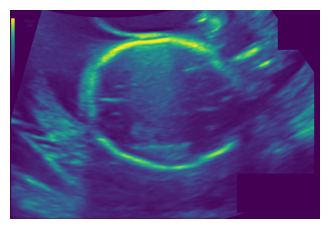

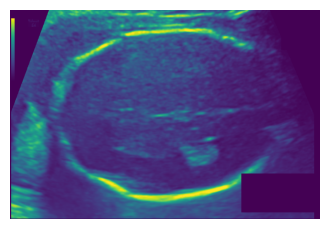

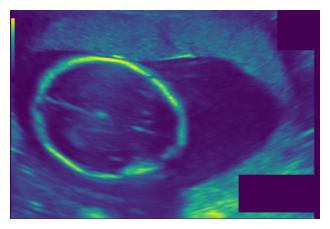

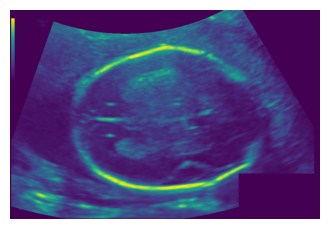

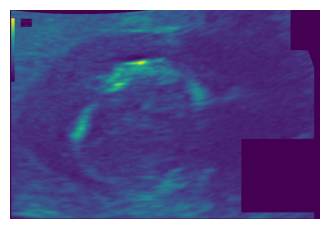

In [ ]:
import matplotlib.pyplot as plt
import os
from PIL import Image

files = os.listdir("/content/filtered_synthetic")[:5]

for f in files:
    img = Image.open(os.path.join("/content/filtered_synthetic", f))
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

### 3.2 Inspect rejected images

Visual check of five images that were filtered out, to confirm the threshold removes low-quality samples.

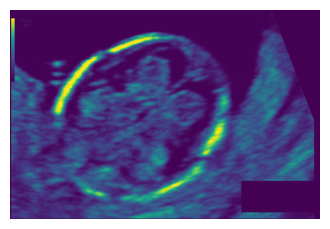

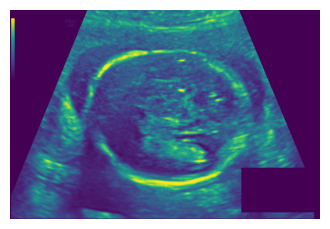

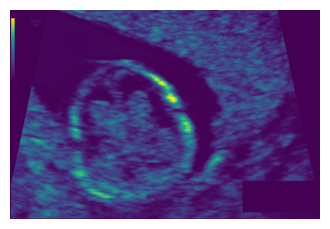

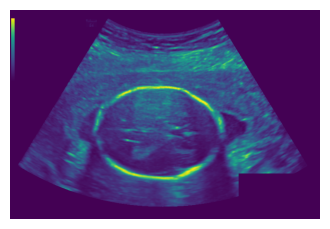

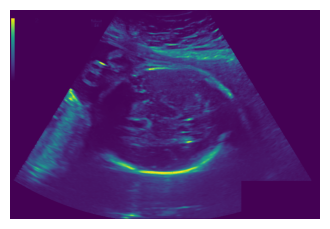

In [ ]:
files = os.listdir("/content/rejected_synthetic")[:5]

for f in files:
    img = Image.open(os.path.join("/content/rejected_synthetic", f))
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

## 4. Realism check (FID)

The Frechet Inception Distance (FID) compares the feature distribution of real images with that of the filtered synthetic images. Lower is better; 0 means identical distributions.

Steps: install `pytorch-fid`, verify folders, check image sizes, resize everything to 256 x 256 RGB PNG, then compute FID.

In [ ]:
# Install pytorch-fid (if not already installed)
!pip install -q pytorch-fid

# Verify folders exist
import os

print("Real images:", os.path.exists(REAL_IMAGES_DIR))
print("Filtered images:", os.path.exists(FILTERED_OUTPUT_DIR))

print("Real image count:", len(os.listdir(REAL_IMAGES_DIR)))
print("Filtered image count:", len(os.listdir(FILTERED_OUTPUT_DIR)))

Real images: True
Filtered images: True
Real image count: 999
Filtered image count: 326


### 4.1 Check image sizes

The raw images have slightly different resolutions (mostly 800 x 540). This cell lists the sizes found and reports unreadable files.

In [ ]:
from PIL import Image
import os
from collections import Counter

sizes = Counter()

for folder in [REAL_IMAGES_DIR, FILTERED_OUTPUT_DIR]:
    print(f"\nChecking: {folder}")

    for f in os.listdir(folder):
        if f.lower().endswith(('.png', '.jpg', '.jpeg')):
            try:
                img = Image.open(os.path.join(folder, f))
                sizes[img.size] += 1
            except Exception as e:
                print("Corrupt image:", f, e)

print("\nImage sizes found:")
print(sizes)


Checking: /content/dataset/train/images

Checking: /content/filtered_synthetic

Image sizes found:
Counter({(800, 540): 1289, (800, 542): 8, (783, 543): 2, (789, 545): 2, (796, 542): 2, (790, 539): 2, (788, 545): 2, (794, 544): 2, (791, 544): 2, (783, 541): 2, (789, 540): 2, (794, 543): 1, (796, 544): 1, (799, 563): 1, (780, 544): 1, (780, 539): 1, (798, 541): 1, (786, 542): 1, (782, 542): 1, (738, 541): 1, (797, 541): 1})


### 4.2 Resize to a common size

FID needs consistent inputs, so all images are converted to 256 x 256 RGB PNG files in `/content/real_fixed` and `/content/syn_fixed`.

In [ ]:
from PIL import Image
import os

REAL_FIXED = "/content/real_fixed"
SYN_FIXED = "/content/syn_fixed"

os.makedirs(REAL_FIXED, exist_ok=True)
os.makedirs(SYN_FIXED, exist_ok=True)

TARGET_SIZE = (256, 256)

def normalize_images(src_dir, dst_dir):
    """Convert every image in src_dir to a 256x256 RGB PNG saved in dst_dir.

    FID (Inception-v3) expects 3-channel inputs of one consistent size.
    """
    count = 0

    for fname in os.listdir(src_dir):
        if fname.lower().endswith((".png", ".jpg", ".jpeg")):
            try:
                img = Image.open(os.path.join(src_dir, fname))
                img = img.convert("RGB")
                img = img.resize(TARGET_SIZE)

                out_name = os.path.splitext(fname)[0] + ".png"
                img.save(os.path.join(dst_dir, out_name))
                count += 1

            except Exception as e:
                print(f"Skipped {fname}: {e}")

    print(f"Processed {count} images")

normalize_images(REAL_IMAGES_DIR, REAL_FIXED)
normalize_images(FILTERED_OUTPUT_DIR, SYN_FIXED)

Processed 999 images
Processed 326 images


### 4.3 Compute FID

Runs `pytorch_fid` on the two resized folders (CPU, batch size 8). The first run downloads the Inception weights (about 91 MB).

**Result in the saved run:** FID = 32.18 (999 real vs 326 filtered images).

In [ ]:
!python -m pytorch_fid \
    /content/real_fixed \
    /content/syn_fixed \
    --device cpu \
    --batch-size 8

Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth
100% 91.2M/91.2M [00:00<00:00, 237MB/s]
100% 125/125 [03:51<00:00,  1.86s/it]
100% 41/41 [01:14<00:00,  1.82s/it]
FID:  32.17696498985049


## 5. Combined dataset

Copies real image-mask pairs and filtered synthetic image-mask pairs into one folder. File names get a `real_` or `syn_` prefix so the source of every sample stays traceable. A synthetic image is only used if a matching mask exists.

**Result in the saved run:** 999 real pairs + 326 synthetic pairs = 1325 pairs (about 75% real, 25% synthetic).

In [ ]:
real_files = [f for f in os.listdir(REAL_IMAGES_DIR)
              if f.lower().endswith('.png')]
real_count = 0

for fname in real_files:
    if os.path.exists(os.path.join(REAL_MASKS_DIR, fname)):
        shutil.copy(os.path.join(REAL_IMAGES_DIR, fname),
                    os.path.join(COMBINED_IMG_DIR,  f"real_{fname}"))
        shutil.copy(os.path.join(REAL_MASKS_DIR,   fname),
                    os.path.join(COMBINED_MASK_DIR, f"real_{fname}"))
        real_count += 1

syn_files = [f for f in os.listdir(FILTERED_OUTPUT_DIR)
             if f.lower().endswith('.png')]
syn_count = 0

for fname in syn_files:
    mask_path = os.path.join(SYN_MASKS_DIR, fname)
    if os.path.exists(mask_path):
        shutil.copy(os.path.join(FILTERED_OUTPUT_DIR, fname),
                    os.path.join(COMBINED_IMG_DIR,  f"syn_{fname}"))
        shutil.copy(mask_path,
                    os.path.join(COMBINED_MASK_DIR, f"syn_{fname}"))
        syn_count += 1
    else:
        print(f"⚠ No mask for: {fname}")

print(f"Real pairs     : {real_count}")
print(f"Synthetic pairs: {syn_count}")
print(f"Total combined : {real_count + syn_count}")

Real pairs     : 999
Synthetic pairs: 326
Total combined : 1325


## 6. Dataset class and U-Net model

**`FetalDataset`** loads an image-mask pair, resizes to 256 x 256 (bilinear for images, nearest-neighbour for masks so labels stay binary), optionally applies augmentation, and binarises the mask at 127.

Augmentations (training only, applied identically to image and mask): horizontal flip, vertical flip, rotation between -20 and +20 degrees, each with probability 0.5.

**`UNet`** is a standard 4-level encoder-decoder with skip connections, trained from scratch:

| Stage | Channels |
|---|---|
| Encoder | 1 -> 64 -> 128 -> 256 -> 512 |
| Bottleneck | 1024 |
| Decoder | 512 -> 256 -> 128 -> 64 |
| Output | 2 (background, fetal head) |

The cell ends with a smoke test: it builds the dataset, checks tensor shapes and labels, and passes a random tensor through the model. Expected output: image `[1, 256, 256]`, mask `[256, 256]`, labels `{0, 1}`, model output `[1, 2, 256, 256]`.

In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset
from PIL import Image

# ==========================
# DATASET
# ==========================

class FetalDataset(Dataset):
    """Paired ultrasound image / binary segmentation mask dataset.

    Args:
        img_dir  (str):  folder with input images.
        mask_dir (str):  folder with masks sharing the same file names.
        img_size (int):  images and masks are resized to img_size x img_size.
        augment  (bool): random h-flip, v-flip and rotation (+/-20 deg),
                         applied identically to image and mask.

    Returns (per item):
        img  : FloatTensor [1, H, W], values in [0, 1]
        mask : LongTensor  [H, W],    values in {0, 1}
    """
    def __init__(self, img_dir, mask_dir, img_size=256, augment=True):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.img_size = img_size
        self.augment = augment

        self.files = sorted([
            f for f in os.listdir(img_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            and os.path.exists(os.path.join(mask_dir, f))
        ])

        print(f"Dataset: {len(self.files)} valid image-mask pairs")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]

        img = Image.open(
            os.path.join(self.img_dir, fname)
        ).convert('L')

        mask = Image.open(
            os.path.join(self.mask_dir, fname)
        ).convert('L')

        img = img.resize((self.img_size, self.img_size), Image.BILINEAR)
        mask = mask.resize((self.img_size, self.img_size), Image.NEAREST)

        if self.augment:

            if random.random() > 0.5:
                img = TF.hflip(img)
                mask = TF.hflip(mask)

            if random.random() > 0.5:
                img = TF.vflip(img)
                mask = TF.vflip(mask)

            if random.random() > 0.5:
                angle = random.randint(-20, 20)
                img = TF.rotate(img, angle)
                mask = TF.rotate(mask, angle)

        img = TF.to_tensor(img)

        mask = torch.from_numpy(
            np.array(mask)
        )

        mask = (mask > 127).long()

        return img, mask


# ==========================
# U-NET
# ==========================

def double_conv(in_ch, out_ch):
    """Two (3x3 Conv -> BatchNorm -> ReLU) layers: the basic U-Net block."""
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),

        nn.Conv2d(out_ch, out_ch, 3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True)
    )


class UNet(nn.Module):
    """Standard 4-level U-Net trained from scratch.

    Input : [B, 1, 256, 256] grayscale ultrasound.
    Output: [B, 2, 256, 256] logits (class 0 = background, class 1 = fetal head).
    Encoder channels 64-128-256-512, bottleneck 1024, skip connections via concat.
    """

    def __init__(self):
        super().__init__()

        self.e1 = double_conv(1, 64)
        self.e2 = double_conv(64, 128)
        self.e3 = double_conv(128, 256)
        self.e4 = double_conv(256, 512)

        self.pool = nn.MaxPool2d(2)

        self.bot = double_conv(512, 1024)

        self.u4 = nn.ConvTranspose2d(1024, 512, 2, 2)
        self.d4 = double_conv(1024, 512)

        self.u3 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.d3 = double_conv(512, 256)

        self.u2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.d2 = double_conv(256, 128)

        self.u1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.d1 = double_conv(128, 64)

        self.out = nn.Conv2d(64, 2, 1)

    def forward(self, x):

        e1 = self.e1(x)

        e2 = self.e2(self.pool(e1))

        e3 = self.e3(self.pool(e2))

        e4 = self.e4(self.pool(e3))

        b = self.bot(self.pool(e4))

        x = self.u4(b)
        x = self.d4(torch.cat([x, e4], dim=1))

        x = self.u3(x)
        x = self.d3(torch.cat([x, e3], dim=1))

        x = self.u2(x)
        x = self.d2(torch.cat([x, e2], dim=1))

        x = self.u1(x)
        x = self.d1(torch.cat([x, e1], dim=1))

        return self.out(x)


# ==========================
# PATHS
# ==========================

IMG_DIR = COMBINED_IMG_DIR
MASK_DIR = COMBINED_MASK_DIR

# ==========================
# TEST DATASET
# ==========================

dataset = FetalDataset(
    IMG_DIR,
    MASK_DIR,
    img_size=256,
    augment=False
)

print("\nDataset Length:", len(dataset))

img, mask = dataset[0]

print("\nImage Shape:", img.shape)
print("Mask Shape :", mask.shape)
print("Mask Labels:", torch.unique(mask))

# ==========================
# TEST MODEL
# ==========================

model = UNet()

print("\nModel Created Successfully")

dummy = torch.randn(1, 1, 256, 256)

output = model(dummy)

print("Output Shape:", output.shape)

print("\nEverything is working correctly.")

Dataset: 1325 valid image-mask pairs

Dataset Length: 1325

Image Shape: torch.Size([1, 256, 256])
Mask Shape : torch.Size([256, 256])
Mask Labels: tensor([0, 1])

Model Created Successfully
Output Shape: torch.Size([1, 2, 256, 256])

Everything is working correctly.


## 7. Loss function and metrics

**`DiceCELoss`** = cross-entropy + (1 - soft Dice). Cross-entropy gives stable per-pixel gradients, while the Dice term directly optimises region overlap and helps with the foreground/background imbalance.

**Metrics** (computed on hard predictions)

- Dice = 2|P intersect T| / (|P| + |T|)
- IoU = |P intersect T| / |P union T|

In [ ]:
import torch
import torch.nn as nn

class DiceCELoss(nn.Module):
    """Cross-entropy + soft Dice loss (Dice computed on the foreground class)."""
    def __init__(self):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()

    def forward(self, logits, targets):
        ce = self.ce(logits, targets)

        prob = torch.softmax(logits, dim=1)[:, 1]
        tgt = targets.float()

        dice = 1 - (
            (2 * (prob * tgt).sum() + 1)
            / (prob.sum() + tgt.sum() + 1)
        )

        return ce + dice


def dice_score(pred, tgt):
    """Dice coefficient for hard predictions (pred, tgt: label tensors)."""
    p = (pred == 1).float()
    t = tgt.float()

    return (
        (2 * (p * t).sum() + 1e-6)
        / (p.sum() + t.sum() + 1e-6)
    ).item()


def iou_score(pred, tgt):
    """Intersection-over-Union for hard predictions (pred, tgt: label tensors)."""
    p = (pred == 1).float()
    t = tgt.float()

    inter = (p * t).sum()
    union = p.sum() + t.sum() - inter

    return (
        (inter + 1e-6)
        / (union + 1e-6)
    ).item()

## 8. Training

| Setting | Value |
|---|---|
| Train / validation split | 85% / 15% (random; 1127 / 198 images) |
| Batch size | 4 |
| Epochs | 20 |
| Optimiser | AdamW (lr 1e-4, weight decay 1e-4) |
| LR schedule | Cosine annealing over all epochs |
| Loss | `DiceCELoss` |
| Augmentation | Training subset only |
| Model selection | Checkpoint with the best validation Dice is saved to `best_model.pth` |

The training and validation subsets are built from two dataset objects (with and without augmentation) that share the same file order, so one set of random indices keeps the split consistent.

The default batch size is small to be CPU friendly. On a GPU runtime you can increase `BATCH_SIZE` and `EPOCHS`.

**Note:** the output saved below ends after epoch 3 (best validation Dice 0.2197), because the run was stopped early. Re-run the cell for the full 20 epochs before quoting final metrics.

In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import numpy as np

# ==============================
# CONFIG
# ==============================
BATCH_SIZE = 4      # CPU friendly
EPOCHS = 20         # Increase later if needed
LR = 1e-4

DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print("Device:", DEVICE)

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ==============================
# DATASETS
# ==============================

train_dataset = FetalDataset(
    COMBINED_IMG_DIR,
    COMBINED_MASK_DIR,
    img_size=256,
    augment=True
)

val_dataset = FetalDataset(
    COMBINED_IMG_DIR,
    COMBINED_MASK_DIR,
    img_size=256,
    augment=False
)

# ==============================
# TRAIN / VAL SPLIT
# ==============================

dataset_size = len(train_dataset)

indices = torch.randperm(dataset_size).tolist()

val_size = int(dataset_size * 0.15)

val_indices = indices[:val_size]
train_indices = indices[val_size:]

train_ds = Subset(train_dataset, train_indices)
val_ds = Subset(val_dataset, val_indices)

print(f"Train: {len(train_ds)}")
print(f"Val  : {len(val_ds)}")

# ==============================
# DATALOADERS
# ==============================

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

# ==============================
# MODEL
# ==============================

model = UNet().to(DEVICE)

criterion = DiceCELoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

# ==============================
# TRAINING LOOP
# ==============================

best_dice = 0.0

history = {
    "train_loss": [],
    "val_loss": [],
    "val_dice": [],
    "val_iou": []
}

for epoch in range(1, EPOCHS + 1):

    # -------------------------
    # TRAIN
    # -------------------------

    model.train()

    train_loss = 0.0

    for imgs, masks in train_loader:

        imgs = imgs.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(imgs)

        loss = criterion(outputs, masks)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # -------------------------
    # VALIDATION
    # -------------------------

    model.eval()

    val_loss = 0.0
    val_dice = 0.0
    val_iou = 0.0

    with torch.no_grad():

        for imgs, masks in val_loader:

            imgs = imgs.to(DEVICE)
            masks = masks.to(DEVICE)

            outputs = model(imgs)

            loss = criterion(outputs, masks)

            preds = outputs.argmax(dim=1)

            val_loss += loss.item()

            val_dice += dice_score(preds, masks)

            val_iou += iou_score(preds, masks)

    val_loss /= len(val_loader)
    val_dice /= len(val_loader)
    val_iou /= len(val_loader)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_dice"].append(val_dice)
    history["val_iou"].append(val_iou)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Dice: {val_dice:.4f} | "
        f"IoU: {val_iou:.4f}"
    )

    # -------------------------
    # SAVE BEST MODEL
    # -------------------------

    if val_dice > best_dice:

        best_dice = val_dice

        torch.save(
            model.state_dict(),
            os.path.join(
                CHECKPOINT_DIR,
                "best_model.pth"
            )
        )

        print(
            f"✅ Best model saved "
            f"(Dice={best_dice:.4f})"
        )

print("\nTraining Complete")
print(f"Best Dice Score: {best_dice:.4f}")

Device: cpu
Dataset: 1325 valid image-mask pairs
Dataset: 1325 valid image-mask pairs
Train: 1127
Val  : 198
Epoch 01/20 | Train Loss: 1.3908 | Val Loss: 1.2246 | Dice: 0.0031 | IoU: 0.0016
✅ Best model saved (Dice=0.0031)
Epoch 02/20 | Train Loss: 1.1508 | Val Loss: 1.0874 | Dice: 0.2158 | IoU: 0.1213
✅ Best model saved (Dice=0.2158)
Epoch 03/20 | Train Loss: 1.0475 | Val Loss: 1.0075 | Dice: 0.2197 | IoU: 0.1236
✅ Best model saved (Dice=0.2197)


## 9. Results and export

### 9.1 Training curves

Plots training/validation loss, validation Dice and validation IoU per epoch and saves the figure as `curves.png` in the checkpoint folder. Run this after training has finished.

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history['train_loss'], label='Train'); axes[0].plot(history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(history['val_dice'], color='green');  axes[1].set_title('Val Dice')
axes[2].plot(history['val_iou'],  color='orange'); axes[2].set_title('Val IoU')
for ax in axes: ax.set_xlabel('Epoch')
plt.tight_layout()
plt.savefig(f"{CHECKPOINT_DIR}/curves.png")
plt.show()

### 9.2 Download the model and plots

Downloads `best_model.pth` (weights of the best epoch by validation Dice) and `curves.png` to your computer. To reload the model later:

```python
model = UNet()
model.load_state_dict(torch.load("best_model.pth", map_location="cpu"))
model.eval()
```

Model weights are not stored in the repository; host them externally (for example Google Drive or Hugging Face) and link them in the README.

In [ ]:
from google.colab import files
files.download(f"{CHECKPOINT_DIR}/best_model.pth")
files.download(f"{CHECKPOINT_DIR}/curves.png")

## 10. Limitations and next steps

**Limitations of this version**

- `GENERATED_IMAGES_DIR` and `SYN_MASKS_DIR` currently point to the real training folders. Until they are changed to the GAN output, the "synthetic" subset is a filtered copy of real images; the FID and the 75/25 mix above reflect that. Because the validation split is drawn after merging, duplicated images can appear in both training and validation and inflate Dice and IoU.
- The notebook covers filtering, dataset building and segmentation. The image-generation stage (for example SPADE and pix2pixHD) is not part of this notebook.
- SSIM against a single mean image is a coarse filter. It favours images close to the average appearance and can reject valid but unusual anatomy.
- Only one random train/validation split is used and there is no separate test set.
- FID is computed on 326 images, which is a small sample, so the value is noisy.

**Suggested next steps**

- Point the generated-image paths to the real synthetic data and re-run Sections 3 to 8.
- Split into train/validation/test before merging, and add synthetic images to the training split only.
- Compare against a real-only baseline to measure the actual benefit of synthetic data.
- Set random seeds and log them for reproducibility.
- Try a pretrained encoder (for example ResNet34 U-Net) and report Dice and IoU on a held-out test set.
- Convert the segmentation mask into a head-circumference measurement.